Total emitted photons (in overlap range): 100015.05
Total detected photoelectrons: 50259.35
Spectral Matching Factor: 50.25%



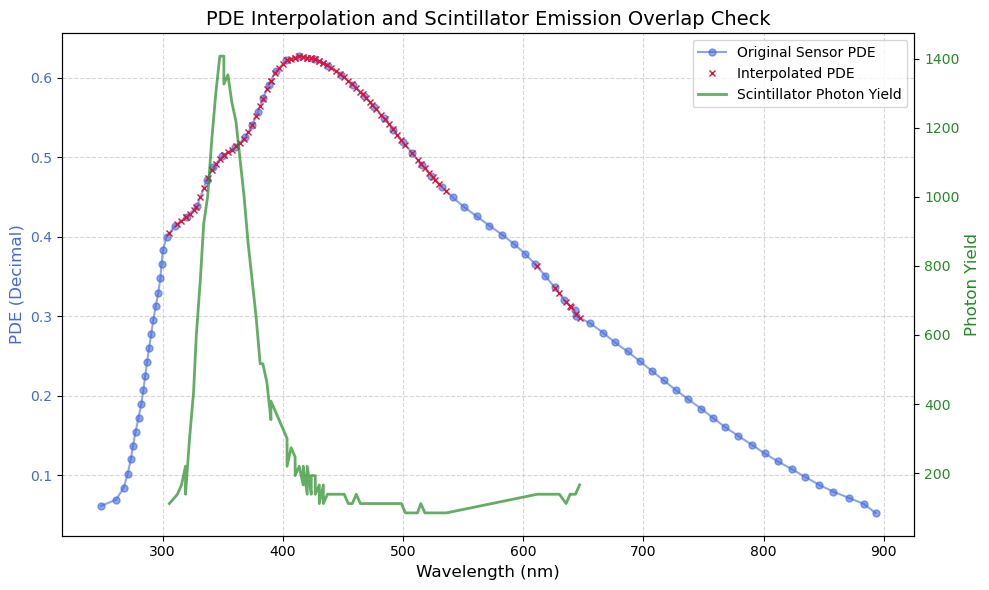

In [6]:
import pandas as pd
import numpy as np
from scipy.interpolate import interp1d
from scipy.integrate import trapezoid
import matplotlib.pyplot as plt

# 1. 讀取數據 (Load Data)
# 加入 sep=r'\s+' 解決 txt 空格分隔問題
df_scint = pd.read_csv('LAS_1%.csv', names=['Wavelength', 'Photon_Yield'], header=0)
df_sensor = pd.read_csv('SiPMPDE.txt', sep=r'\s+', names=['Wavelength', 'PDE_percent'], header=0)

wave_scint = df_scint['Wavelength'].values
yield_scint = df_scint['Photon_Yield'].values

wave_sensor = df_sensor['Wavelength'].values
pde_sensor = df_sensor['PDE_percent'].values / 100.0 

# 2. 數據排序 (Sort Data - Fix for Negative Integral)
# 確保 Wavelength 由細到大排列，否則 trapezoid 積分會出負數
sort_idx_scint = np.argsort(wave_scint)
wave_scint = wave_scint[sort_idx_scint]
yield_scint = yield_scint[sort_idx_scint]

sort_idx_sensor = np.argsort(wave_sensor)
wave_sensor = wave_sensor[sort_idx_sensor]
pde_sensor = pde_sensor[sort_idx_sensor]

# 3. 決定重疊嘅波長範圍 (Determine Overlap Range)
min_wave = max(wave_scint.min(), wave_sensor.min())
max_wave = min(wave_scint.max(), wave_sensor.max())

valid_idx = (wave_scint >= min_wave) & (wave_scint <= max_wave)
wave_common = wave_scint[valid_idx]
yield_common = yield_scint[valid_idx]

# 4. 數據插值 (Interpolation)
pde_interp_func = interp1d(wave_sensor, pde_sensor, kind='linear', bounds_error=False, fill_value=0)
pde_common = pde_interp_func(wave_common)

# 5. 計算重疊與積分 (Convolution / Overlap Integration)
effective_yield = yield_common * pde_common
detected_photons = trapezoid(effective_yield, wave_common)
total_photons = trapezoid(yield_common, wave_common)
matching_factor = detected_photons / total_photons

# 6. 輸出結果 (Print Results)
print(f"Total emitted photons (in overlap range): {total_photons:.2f}")
print(f"Total detected photoelectrons: {detected_photons:.2f}")
print(f"Spectral Matching Factor: {matching_factor * 100:.2f}%\n")

# 7. 繪製檢查圖 (Plot Interpolation Check)
fig, ax1 = plt.subplots(figsize=(10, 6), dpi=100)

# 畫出原裝 PDE 同 Interpolated PDE
ax1.plot(wave_sensor, pde_sensor, 'o-', label='Original Sensor PDE', color='royalblue', markersize=5, alpha=0.6)
ax1.plot(wave_common, pde_common, 'x', label='Interpolated PDE', color='crimson', markersize=4)
ax1.set_xlabel('Wavelength (nm)', fontsize=12)
ax1.set_ylabel('PDE (Decimal)', color='royalblue', fontsize=12)
ax1.tick_params(axis='y', labelcolor='royalblue')
ax1.grid(True, linestyle='--', alpha=0.5)

# 加入第二個 Y 軸，畫出 Scintillator Emission
ax2 = ax1.twinx()
ax2.plot(wave_common, yield_common, '-', label='Scintillator Photon Yield', color='forestgreen', linewidth=2, alpha=0.7)
ax2.set_ylabel('Photon Yield', color='forestgreen', fontsize=12)
ax2.tick_params(axis='y', labelcolor='forestgreen')

# 合併圖例 (Legends)
lines_1, labels_1 = ax1.get_legend_handles_labels()
lines_2, labels_2 = ax2.get_legend_handles_labels()
ax1.legend(lines_1 + lines_2, labels_1 + labels_2, loc='upper right')

plt.title('PDE Interpolation and Scintillator Emission Overlap Check', fontsize=14)
plt.tight_layout()
plt.show()

In [3]:
import pandas as pd
import numpy as np
from scipy.integrate import trapezoid

# 1. 讀取數據 (Load Data)
input_filename = 'LAB_DayaBay.csv'
output_filename = 'LAB_DayaBay_Normalized.csv'

# 使用預設嘅 CSV 讀取方式，並嘗試處理可能存在嘅空格
df_scint = pd.read_csv(input_filename, sep=',', names=['Wavelength', 'Photon_Yield'], header=0, skipinitialspace=True)

# ---------------------------------------------------------
# 新增：數據清洗步驟 (Data Cleaning Step)
# ---------------------------------------------------------
# 強制將兩欄轉換為數字。如果遇到文字或無效格式 (例如 "--")，errors='coerce' 會自動將佢變成 NaN
df_scint['Wavelength'] = pd.to_numeric(df_scint['Wavelength'], errors='coerce')
df_scint['Photon_Yield'] = pd.to_numeric(df_scint['Photon_Yield'], errors='coerce')

# 剔除所有包含 NaN 嘅行 (Drop missing values)
df_scint = df_scint.dropna()
# ---------------------------------------------------------

wave_scint = df_scint['Wavelength'].values
yield_scint = df_scint['Photon_Yield'].values

# 2. 數據排序 (Sort Data) 
sort_idx = np.argsort(wave_scint)
wave_scint = wave_scint[sort_idx]
yield_scint = yield_scint[sort_idx]

# 3. 計算總積分面積 (Calculate Total Integral Area)
total_area = trapezoid(yield_scint, wave_scint)

# 增加一個安全檢查，確保總面積大於 0
if total_area <= 0 or np.isnan(total_area):
    print(f"Error: Invalid total area ({total_area}). Please manually check '{input_filename}' for formatting issues.")
else:
    print(f"Original Total Area (Integral): {total_area:.4f}")

    # 4. 數據歸一化 (Normalization)
    normalized_yield = yield_scint / total_area

    # 驗證新嘅積分是否等於 1 (Verification)
    new_area = trapezoid(normalized_yield, wave_scint)
    print(f"New Total Area (Integral after normalization): {new_area:.4f}")

    # 5. 儲存至新嘅 CSV 檔案 (Save to new CSV)
    df_normalized = pd.DataFrame({
        'Wavelength': wave_scint,
        'Normalized_Yield': normalized_yield
    })

    df_normalized.to_csv(output_filename, index=False)
    print(f"\nSuccess! Normalized spectrum saved to: {output_filename}")

Original Total Area (Integral): 729600.1348
New Total Area (Integral after normalization): 1.0000

Success! Normalized spectrum saved to: LAB_DayaBay_Normalized.csv
